In [52]:
import obspy
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import swspy

In [113]:
# Import miniSEED file
st = obspy.read("test_waveforms.mseed")

st.filter("highpass", freq=10.0) 

113 Trace(s) in Stream:

OO.AXEC2..HHE | 2014-11-04T20:46:01.600000Z - 2014-11-04T20:46:21.600000Z | 200.0 Hz, 4001 samples
...
(111 other traces)
...
OO.AXBA1..HHZ | 2014-11-06T00:09:38.000000Z - 2014-11-06T00:09:58.000000Z | 200.0 Hz, 4001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [114]:

st_0 = st.select(station='AXAS2')
st_0 = st_0.trim(starttime=st[0].stats.starttime)
st_0 = st_0.trim(endtime=st_0[0].stats.starttime + 15)

In [115]:
st_0

3 Trace(s) in Stream:
OO.AXAS2..EHE | 2014-11-04T20:46:01.600000Z - 2014-11-04T20:46:16.600000Z | 200.0 Hz, 3001 samples
OO.AXAS2..EHN | 2014-11-04T20:46:01.600000Z - 2014-11-04T20:46:16.600000Z | 200.0 Hz, 3001 samples
OO.AXAS2..EHZ | 2014-11-04T20:46:01.600000Z - 2014-11-04T20:46:16.600000Z | 200.0 Hz, 3001 samples

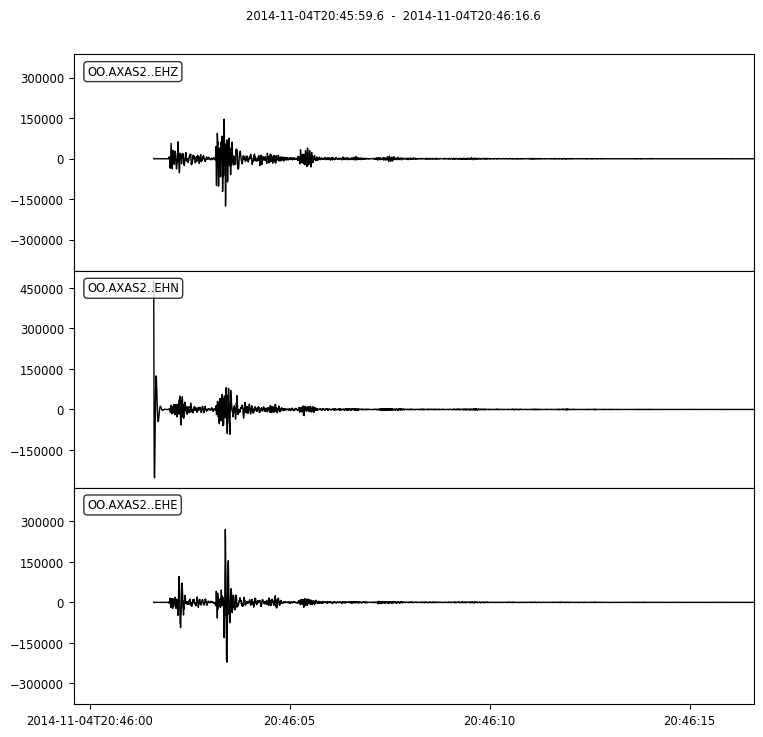

In [116]:
st_0.plot(title="Waveform for Earthquake 0 at AXAS2", ylabel="Amplitude", xlabel="Time (s)",
          starttime=st_0[0].stats.starttime -2, endtime=st_0[0].stats.starttime +15 )

plt.show()

In [117]:
# Import station data from CSV file
station_data = pd.read_csv('../data/axial_seamount_stations.csv')
station_data.columns = ['station_id', 'location_name', 'lat', 'lon', 'elev']

# Display the station data
print("Axial Seamount Station Data:")
print("=" * 50)
print(station_data)
print(f"\nTotal stations: {len(station_data)}")


Axial Seamount Station Data:
  station_id            location_name     lat      lon  elev
0      AXAS1            Axial Ashes 1  45.936 -130.013 -1516
1      AXAS2            Axial Ashes 2  45.936 -130.013 -1516
2      AXBA1             Axial Base 1  45.550 -130.000 -2600
3      AXCC1  Axial Central Caldera 1  45.955 -130.008 -1516
4      AXEC1     Axial East Caldera 1  45.955 -129.973 -1519
5      AXEC2     Axial East Caldera 2  45.955 -129.973 -1519
6      AXEC3     Axial East Caldera 3  45.955 -129.973 -1519
7      AXID1      Axial International  45.934 -130.004 -1512

Total stations: 8


In [129]:
# Calculate back-azimuth and angle of incidence with station coordinates
import numpy as np

def calculate_epicentral_distance_km(eq_lat, eq_lon, sta_lat, sta_lon):
    """Calculate epicentral distance using haversine formula"""
    # Convert to radians
    eq_lat_rad = np.radians(eq_lat)
    eq_lon_rad = np.radians(eq_lon)
    sta_lat_rad = np.radians(sta_lat)
    sta_lon_rad = np.radians(sta_lon)
    
    # Haversine formula
    dlat = eq_lat_rad - sta_lat_rad
    dlon = eq_lon_rad - sta_lon_rad
    a = np.sin(dlat/2)**2 + np.cos(sta_lat_rad) * np.cos(eq_lat_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Earth radius in km
    R = 6371.0
    distance_km = R * c
    
    return distance_km

def calculate_back_azimuth(eq_lat, eq_lon, sta_lat, sta_lon):
    """Calculate back-azimuth from station to earthquake (0-360°)"""
    # Convert to radians
    eq_lat_rad = np.radians(eq_lat)
    eq_lon_rad = np.radians(eq_lon)
    sta_lat_rad = np.radians(sta_lat)
    sta_lon_rad = np.radians(sta_lon)
    
    # Calculate back-azimuth
    dlon = eq_lon_rad - sta_lon_rad
    y = np.sin(dlon) * np.cos(eq_lat_rad)
    x = (np.cos(sta_lat_rad) * np.sin(eq_lat_rad) - 
         np.sin(sta_lat_rad) * np.cos(eq_lat_rad) * np.cos(dlon))
    
    back_az = np.degrees(np.arctan2(y, x))
    
    # Normalize to 0-360°
    back_az = (back_az + 360) % 360
    
    return back_az

def calculate_angle_of_incidence(epicentral_dist_km, eq_depth_km, sta_elevation_km=0):
    """
    Calculate angle of incidence from vertical
    Simple geometric approach - assumes straight ray path
    """
    # Convert elevation from meters to km if needed
    if abs(sta_elevation_km) > 100:  # Likely in meters
        sta_elevation_km = sta_elevation_km / 1000.0
    
    # Adjust depth for station elevation (depth below station)
    effective_depth = eq_depth_km - sta_elevation_km  # Note: elevation is typically negative for ocean bottom
    
    # Angle from vertical = arctan(horizontal_distance / depth)
    angle_of_incidence = np.degrees(np.arctan2(epicentral_dist_km, effective_depth))
    
    return angle_of_incidence

# Example earthquake coordinates (you'd get these from your catalog)
eq_lat = 45.93439  # Example earthquake latitude
eq_lon = -130.02092  # Example earthquake longitude  
eq_depth_km = 1.148  # Example earthquake depth in km

print(f"\nStation-Earthquake Geometry Calculations")
print(f"Earthquake: Lat={eq_lat:.4f}°, Lon={eq_lon:.4f}°, Depth={eq_depth_km:.1f}km")
print("=" * 70)

# Calculate for all stations in the dataset
for index, station in station_data.iterrows():
    station_id = station['station_id']
    sta_lat = station['lat']
    sta_lon = station['lon']
    sta_elev = station['elev']
    
    # Calculate distances and angles
    epicentral_dist = calculate_epicentral_distance_km(eq_lat, eq_lon, sta_lat, sta_lon)
    back_azimuth = calculate_back_azimuth(eq_lat, eq_lon, sta_lat, sta_lon)
    angle_of_incidence = calculate_angle_of_incidence(epicentral_dist, eq_depth_km, sta_elev)
    
    print(f"\n{station_id} ({station['location_name']}):")
    print(f"  Station coords: {sta_lat:.4f}°, {sta_lon:.4f}°, {sta_elev:.1f}m")
    print(f"  Epicentral distance: {epicentral_dist:.2f} km")
    print(f"  Back-azimuth: {back_azimuth:.1f}°")
    print(f"  Angle of incidence: {angle_of_incidence:.1f}° from vertical")
    
    # Quality assessment for shear-wave splitting
    if angle_of_incidence <= 35:
        quality = "GOOD (≤35°)"
    elif angle_of_incidence <= 45:
        quality = "FAIR (35-45°)"
    else:
        quality = "POOR (>45°)"
    
    print(f"  Quality for splitting: {quality}")

print("\n" + "=" * 70)
print("Notes:")
print("- Back-azimuth: Direction FROM station TO earthquake")
print("- Angle of incidence: Angle from vertical (0° = straight down)")
print("- For shear-wave splitting: prefer angles ≤35° from vertical")
print("- Elevation: Negative values = below sea level (ocean bottom seismometers)")


Station-Earthquake Geometry Calculations
Earthquake: Lat=45.9344°, Lon=-130.0209°, Depth=1.1km

AXAS1 (Axial Ashes 1):
  Station coords: 45.9360°, -130.0130°, -1516.0m
  Epicentral distance: 0.64 km
  Back-azimuth: 253.7°
  Angle of incidence: 13.5° from vertical
  Quality for splitting: GOOD (≤35°)

AXAS2 (Axial Ashes 2):
  Station coords: 45.9360°, -130.0130°, -1516.0m
  Epicentral distance: 0.64 km
  Back-azimuth: 253.7°
  Angle of incidence: 13.5° from vertical
  Quality for splitting: GOOD (≤35°)

AXBA1 (Axial Base 1):
  Station coords: 45.5500°, -130.0000°, -2600.0m
  Epicentral distance: 42.77 km
  Back-azimuth: 357.8°
  Angle of incidence: 85.0° from vertical
  Quality for splitting: POOR (>45°)

AXCC1 (Axial Central Caldera 1):
  Station coords: 45.9550°, -130.0080°, -1516.0m
  Epicentral distance: 2.50 km
  Back-azimuth: 203.6°
  Angle of incidence: 43.2° from vertical
  Quality for splitting: FAIR (35-45°)

AXEC1 (Axial East Caldera 1):
  Station coords: 45.9550°, -129.9730

In [130]:
# Helper function to get back-azimuth and angle of incidence for specific station-earthquake pairs
def get_station_earthquake_geometry(station_id, eq_lat, eq_lon, eq_depth_km, station_data=station_data):
    """
    Get back-azimuth and angle of incidence for a specific station-earthquake pair
    
    Parameters:
    -----------
    station_id : str
        Station identifier (e.g., 'AXAS2')
    eq_lat, eq_lon : float
        Earthquake latitude and longitude
    eq_depth_km : float
        Earthquake depth in km
    station_data : pandas.DataFrame
        Station coordinates dataframe
        
    Returns:
    --------
    dict : Dictionary with geometry parameters
    """
    
    # Find station in dataframe
    station_row = station_data[station_data['station_id'] == station_id]
    
    if len(station_row) == 0:
        print(f"Warning: Station {station_id} not found in station_data")
        return None
    
    station_info = station_row.iloc[0]
    sta_lat = station_info['lat']
    sta_lon = station_info['lon'] 
    sta_elev = station_info['elev']
    
    # Calculate geometry
    epicentral_dist = calculate_epicentral_distance_km(eq_lat, eq_lon, sta_lat, sta_lon)
    back_azimuth = calculate_back_azimuth(eq_lat, eq_lon, sta_lat, sta_lon)
    angle_of_incidence = calculate_angle_of_incidence(epicentral_dist, eq_depth_km, sta_elev)
    
    return {
        'station_id': station_id,
        'station_name': station_info['location_name'],
        'epicentral_distance_km': epicentral_dist,
        'back_azimuth_deg': back_azimuth,
        'angle_of_incidence_deg': angle_of_incidence,
        'quality': 'GOOD' if angle_of_incidence <= 35 else 'FAIR' if angle_of_incidence <= 45 else 'POOR'
    }

# Example usage with your splitting analysis
print("Example usage for splitting analysis:")
print("=" * 40)

# Get geometry for AXAS2 (the station you're using in swspy)
axas2_geometry = get_station_earthquake_geometry('AXAS2', eq_lat, eq_lon, eq_depth_km)

if axas2_geometry:
    print(f"Station: {axas2_geometry['station_id']}")
    print(f"Back-azimuth: {axas2_geometry['back_azimuth_deg']:.1f}°")
    print(f"Angle of incidence: {axas2_geometry['angle_of_incidence_deg']:.1f}°")
    print(f"Quality: {axas2_geometry['quality']}")
    print()
    print("You can now use this back-azimuth in your swspy analysis:")
    print(f"back_azis_all_stations=[{axas2_geometry['back_azimuth_deg']:.1f}]")
    print(f"receiver_inc_angles_all_stations=[{axas2_geometry['angle_of_incidence_deg']:.1f}]")
else:
    print("Could not find AXAS2 in station data")

Example usage for splitting analysis:
Station: AXAS2
Back-azimuth: 253.7°
Angle of incidence: 13.5°
Quality: GOOD

You can now use this back-azimuth in your swspy analysis:
back_azis_all_stations=[253.7]
receiver_inc_angles_all_stations=[13.5]


In [131]:
splitting_event = swspy.splitting.create_splitting_object(st_0, stations_in=['AXAS2'], 
                                                          back_azis_all_stations=[253.7], receiver_inc_angles_all_stations=[13.5], 
                                                          S_phase_arrival_times=[st_0[0].stats.starttime + 0.220])

In [132]:
splitting_event.overall_win_start_pre_fast_S_pick = 0.3
splitting_event.win_S_pick_tolerance = 0.1
splitting_event.overall_win_start_post_fast_S_pick = 0.2 
splitting_event.rotate_step_deg = 1.0 
splitting_event.max_t_shift_s = 0.1 
splitting_event.n_win = 10

In [133]:
splitting_event.perform_sws_analysis(coord_system="ZNE", sws_method="EV_and_XC") #(coord_system="LQT") #(coord_system="ZNE")

,station,phi_from_Q,phi_from_N,phi_from_U,phi_err,dt,dt_err,src_pol_from_N,src_pol_from_U,src_pol_from_N_err,src_pol_from_U_err,Q_w,lambda2/lambda1 ratio,ray_back_azi,ray_inc
0,AXAS2,16.0,89.7,76.5,1.5,0.07,0.005,1.076193,91.769947,2.102323,6.314294,0.626394,0.004918,253.7,13.5


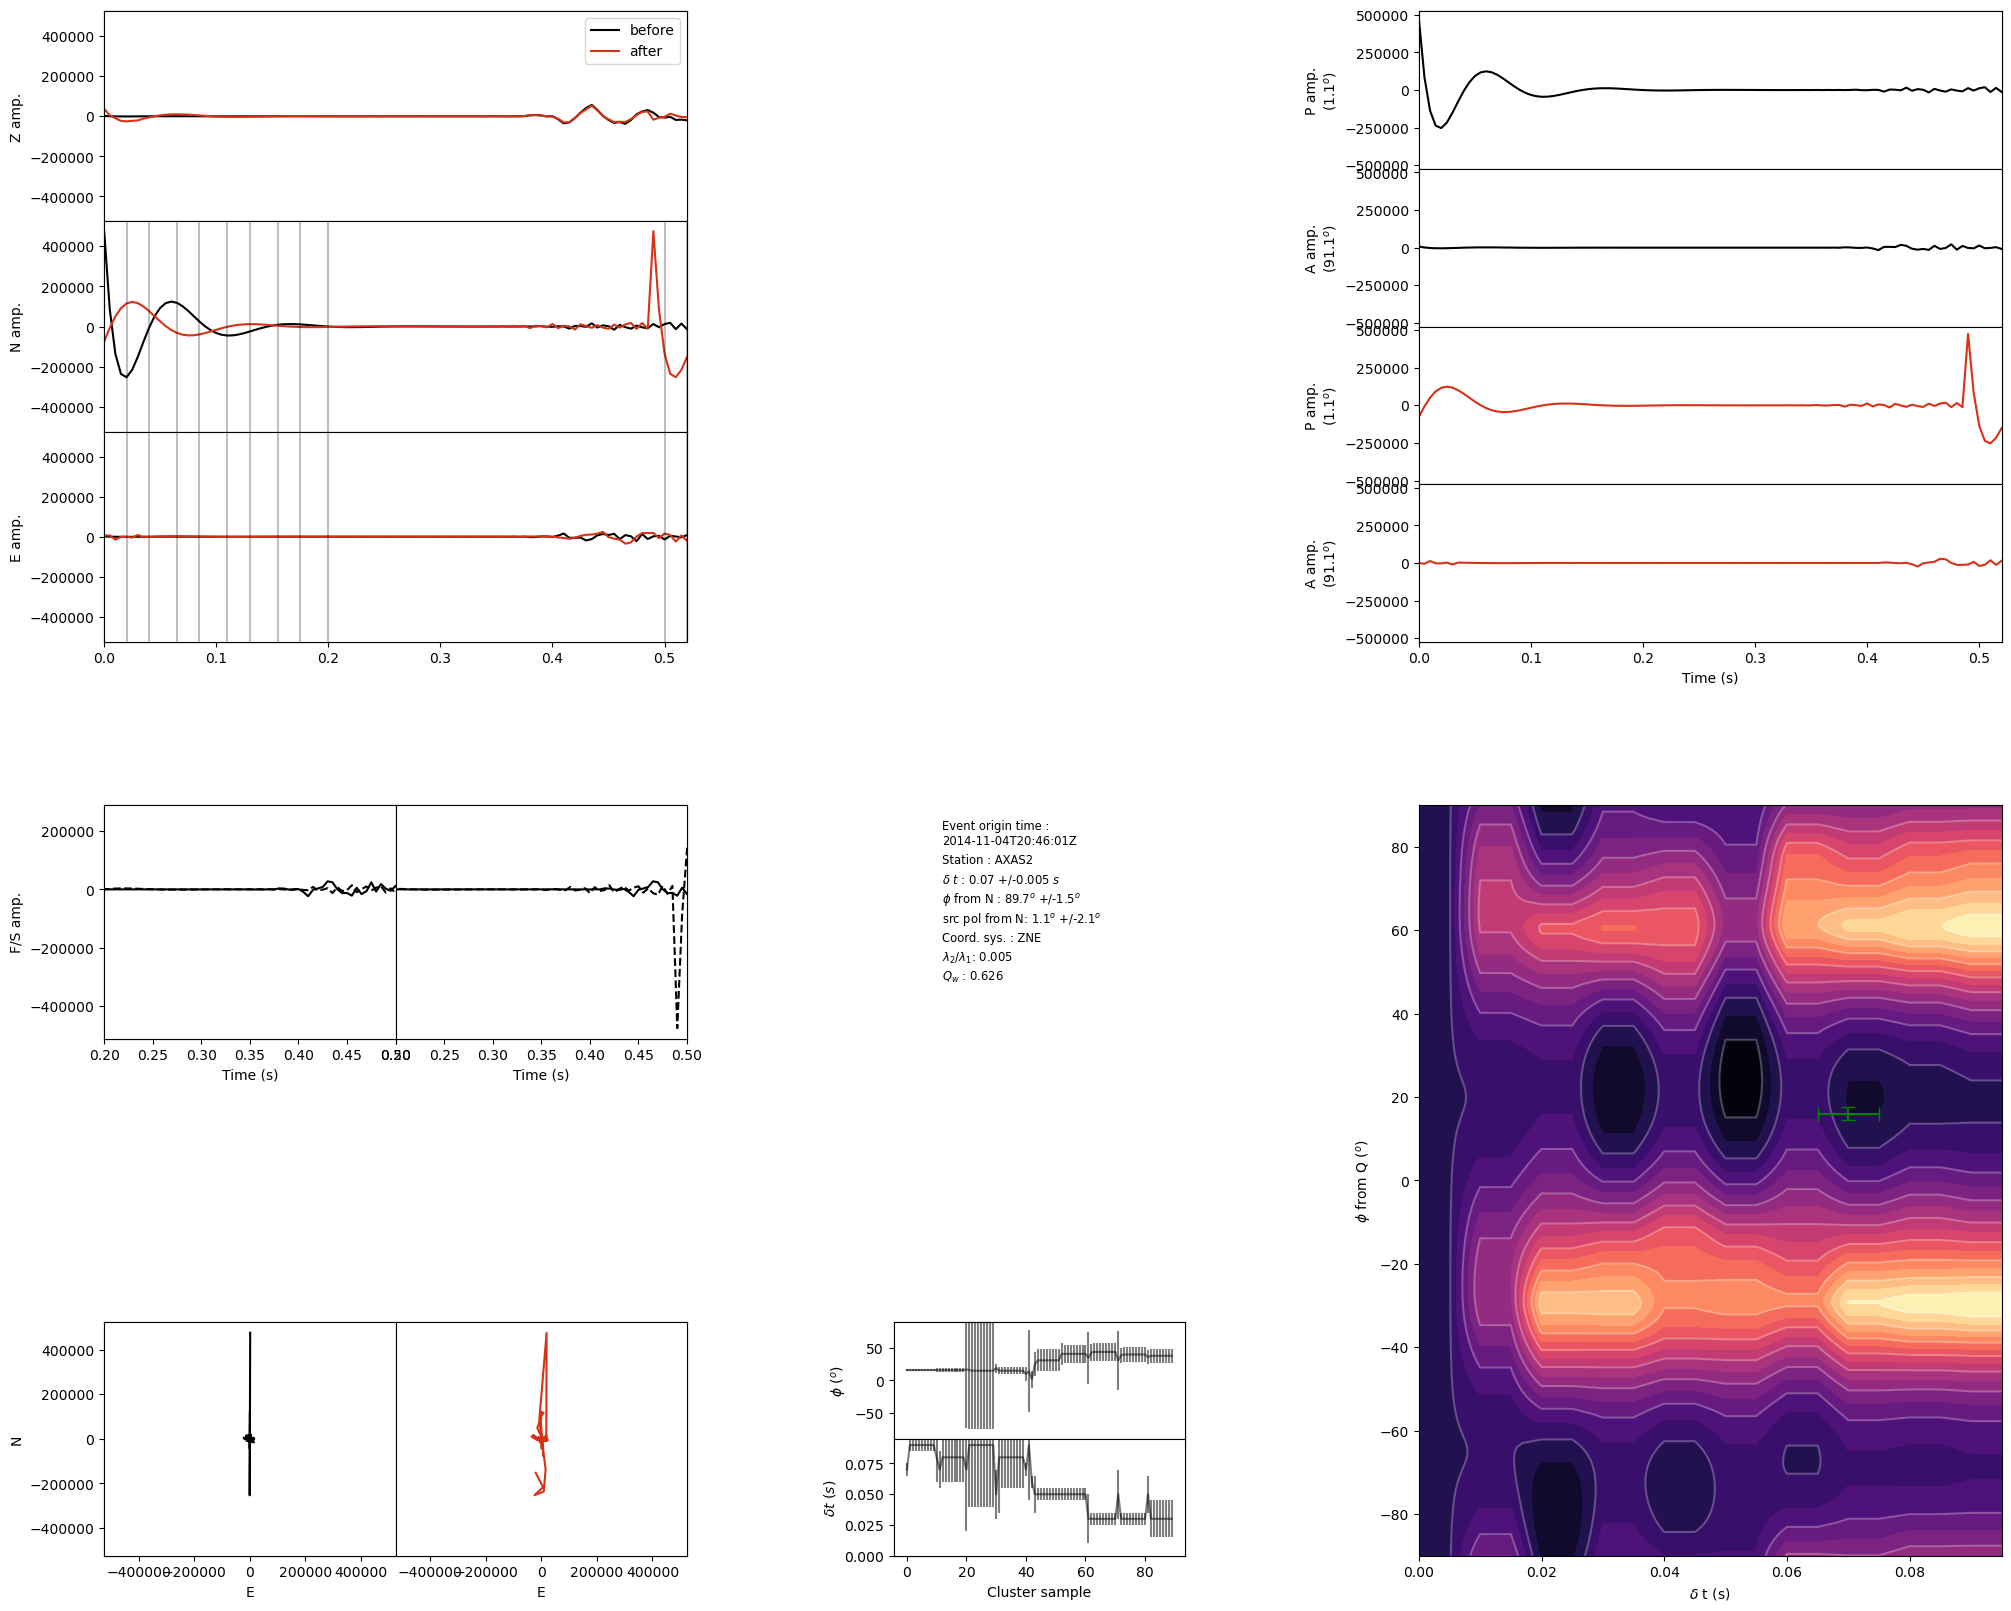

In [134]:
splitting_event.plot()